# Bulk Silicon: SCF, DOS, and Band Structure with QEpy + ASE

This notebook demonstrates a compact electronic-structure workflow for bulk Si:

1. Build a bulk silicon structure
2. Run a ground-state SCF calculation
3. Compute and plot density of states (DOS)
4. Compute and plot band structure along a high-symmetry path

It is designed as a lightweight QEpy example showing how to move from SCF to derived properties (DOS and bands) in one notebook.

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install f90wrap<0.3.0
!pip install qepy
!pip install dftpy
!pip install matplotlib

In [4]:
import numpy as np
from qepy.calculator import QEpyCalculator
from qepy.io import QEInput

In [5]:
from ase.io.trajectory import Trajectory
from ase.lattice.hexagonal import Graphene
from ase import Atoms
import matplotlib.pyplot as plt

In [ ]:
#!wget https://pseudopotentials.quantum-espresso.org/upf_files/Si.pbe-n-kjpaw_psl.1.0.0.UPF #For Linux
!curl https://pseudopotentials.quantum-espresso.org/upf_files/Si.pbe-n-kjpaw_psl.1.0.0.UPF > Si.pbe-n-kjpaw_psl.1.0.0.UPF #For Mac

## 2) Define QE options (`qe_options`)

Set core QE control/system/electrons parameters for bulk Si:
- pseudopotential settings
- cutoff and occupations
- convergence controls
- k-point defaults for SCF

In [18]:
qe_options = {
    '&control': {
        'calculation': "'scf'",
        'prefix': "'tmp'",
        'pseudo_dir': "'./'",
    },
    '&system': {
        'ibrav': 0,
        'ecutwfc': 20,
        'ecutrho': 200,
    },
    '&electrons': {
        'conv_thr': 1.0e-8,
    },
    'atomic_species': ['Si 28.0855 Si.pbe-n-kjpaw_psl.1.0.0.UPF'],
    'k_points automatic': ['9 9 1 0 0 0'],
}


## 3) Build bulk Si structure

Create the silicon crystal structure with ASE and attach the QEpy calculator object.

In [ ]:
from ase.build import bulk
atoms = Atoms(Graphene('Si', latticeconstant={'a':2.46, 'c': 7}))
atoms = bulk('Si', 'diamond', a=5.43)

## 4) Ground-state SCF calculation

Run an SCF energy evaluation to generate a converged charge density and Kohn-Sham states.
This serves as the baseline for DOS and band calculations.

In [ ]:
calc = QEpyCalculator(qe_options=qe_options, logfile='Si_ex.out')
atoms.calc=calc
energy = atoms.get_potential_energy()
efermi = calc.get_fermi_level()
print(efermi)

6.389913305004183


## 5) Density of States (DOS)

Increase k-point density for smoother DOS, compute DOS from the converged state, and plot DOS vs energy.

In [46]:
qe_options['k_points automatic']= ['8 8 8 0 0 0']
energies, dos =  atoms.calc.get_dos(qe_options, width=0.6)

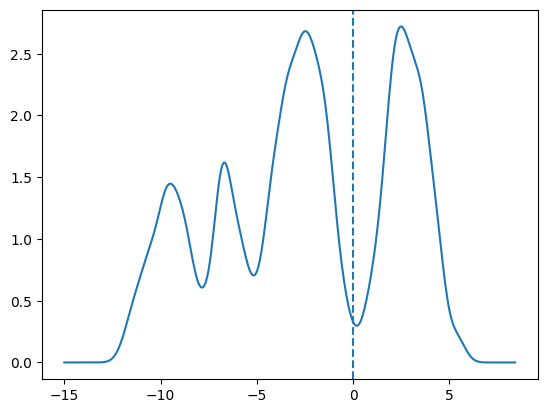

In [47]:
plt.plot(energies, dos)
plt.axvline(x=0, ls='--')

## 6) Band-path definition

Build a high-symmetry reciprocal-space path (ASE `bandpath`) for Si and prepare calculator settings for band evaluation.

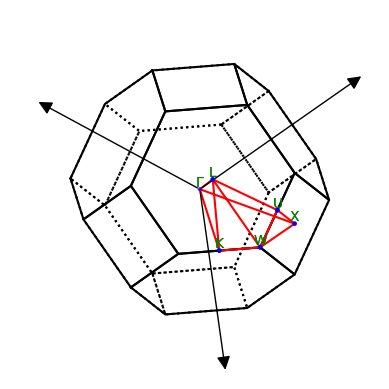

FCC(a=5.43)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



In [48]:
lat = atoms.cell.get_bravais_lattice()
lat.plot_bz(show=True)
print(lat.description())

In [49]:
path = atoms.cell.bandpath('GKLG',npoints=61)

## 7) Band structure

Run the band calculation along the selected k-path and plot energy bands.
Adjust `nbnd` if you want more conduction bands in the plot.

In [50]:
qe_options['&system']['nbnd']=6
band = atoms.calc.get_band_structure(qe_options, kpts=path, reference=efermi)

(-8.0, 15.0)

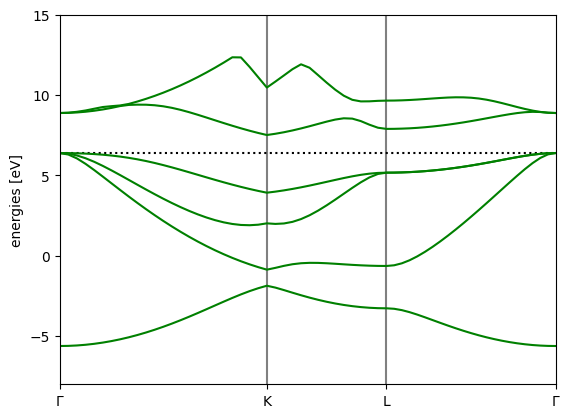

In [51]:
bp=band.plot()
bp.set_ylim(-8,15)

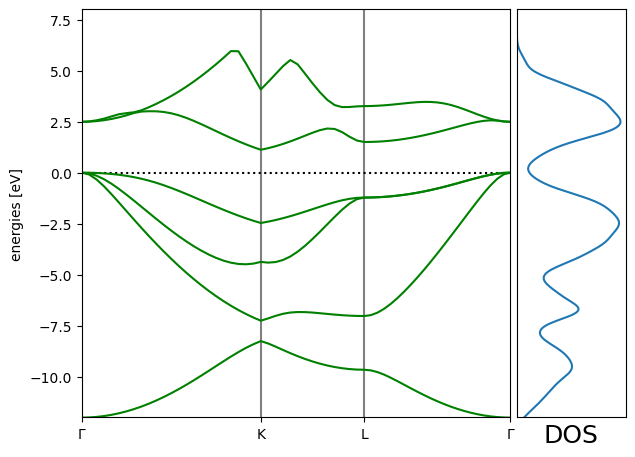

In [52]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_axes([.12, .07, .67, .85])

emin = -12.0
emax = 8.0

bands = band.subtract_reference()
bands.plot(ax=ax, emin=emin, emax=emax)

dosax = fig.add_axes([.8, .07, .17, .85])
dosax.plot(dos, energies)

dosax.set_ylim(emin, emax)
dosax.set_xlim(0, None)
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS", fontsize=18);